<a href="https://colab.research.google.com/github/DiyaZahra/iris-streamlit-app/blob/main/Copy_of_iris_ann_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
import sklearn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.70      0.78        10
           2       0.75      0.90      0.82        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.3333 - loss: 0.9728
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3333 - loss: 0.9253
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3667 - loss: 0.8811
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4500 - loss: 0.8389
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6167 - loss: 0.8038
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.7721
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7167 - loss: 0.7443
E

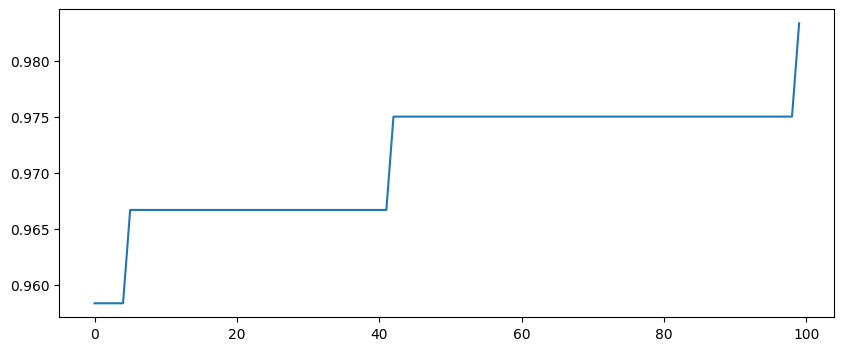

In [ ]:
df = sns.load_dataset('iris')
df.head()
df['species'].value_counts()
X = df.drop(columns = ['species'], axis=1)
y = df['species']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

# perceptron model
perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron.fit(X_train_scaled, y_train)
y_pred = perceptron.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


#artificial neural network
y_train_categorical = to_categorical(y_train, num_classes = 3)
y_test_categorical = to_categorical(y_test, num_classes = 3)

model = Sequential([
    Dense(16, input_dim=4, activation='relu'),
    Dense(8, activation = 'relu'),
    Dense(3, activation='softmax')

])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_scaled, y_train_categorical, epochs=100, batch_size=32, verbose=1)
y_pred_nn = model.predict(X_test_scaled)

history = model.fit(X_train_scaled, y_train_categorical, epochs=100, batch_size=32, verbose=1)
history
loss , acc = model.evaluate(X_test_scaled, y_test_categorical, verbose=1)
acc
plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'], label = 'train accuracy')
plt.show()

In [ ]:
import gradio as gr
import numpy as np

def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    features_scaled = standard_scaler.transform(features)
    prediction = model.predict(features_scaled)
    species = ['Setosa', 'Versicolor', 'Virginica']
    return species[np.argmax(prediction)]

demo = gr.Interface(
    fn=predict_species,
    inputs=[
        gr.Number(label="Sepal Length"),
        gr.Number(label="Sepal Width"),
        gr.Number(label="Petal Length"),
        gr.Number(label="Petal Width"),
    ],
    outputs=gr.Textbox(label="Predicted Species")
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69f9ad09308daae049.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("Iris Species Predictor")

sepal_length = st.number_input("Sepal Length")
sepal_width = st.number_input("Sepal Width")
petal_length = st.number_input("Petal Length")
petal_width = st.number_input("Petal Width")

if st.button("Predict"):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    features_scaled = standard_scaler.transform(features)
    prediction = model.predict(features_scaled)
    species = ['Setosa', 'Versicolor', 'Virginica']
    st.success(f"Predicted Species: {species[np.argmax(prediction)]}")

Overwriting app.py


In [ ]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(standard_scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn
numpy
joblib

Overwriting requirements.txt


In [ ]:
!pip show scikit-learn numpy joblib

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn==1.6.1
numpy==2.1.3
joblib

Overwriting requirements.txt


In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn==1.6.1
numpy==2.1.3
joblib
dill
tensorflow
keras

Overwriting requirements.txt


In [ ]:
model.save('model.keras')


In [ ]:
import joblib
joblib.dump(standard_scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib
from tensorflow import keras

model = keras.models.load_model('model.keras')
scaler = joblib.load('scaler.pkl')

st.title("Iris Species Predictor")

sepal_length = st.number_input("Sepal Length")
sepal_width = st.number_input("Sepal Width")
petal_length = st.number_input("Petal Length")
petal_width = st.number_input("Petal Width")

if st.button("Predict"):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)
    species = ['Setosa', 'Versicolor', 'Virginica']
    st.success(f"Predicted Species: {species[np.argmax(prediction)]}")

Overwriting app.py


In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn==1.6.1
numpy==2.1.3
joblib
tensorflow

Overwriting requirements.txt
